In [1]:
import numpy as np
import pandas as pd
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold, train_test_split

from utils import (
    load_data, evaluate_model, save_metrics, plot_feature_importance,
    NUMERIC_FEATURES_TREES, MODELS_DIR
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

CAT_FEATURES = ["metro_station", "renovation"]
FEATURES = NUMERIC_FEATURES_TREES + CAT_FEATURES
print("Признаки для CatBoost:", FEATURES)
print("Категориальные:", CAT_FEATURES)


C:\Users\roman\PycharmProjects\real_estate_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Признаки для CatBoost: ['area', 'rooms', 'floor', 'total_floors', 'minutes_to_metro', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'is_studio', 'metro_station', 'renovation']
Категориальные: ['metro_station', 'renovation']


Загрузка данных

In [2]:
X_train, X_test, y_train, y_test, _, _ = load_data()

# Берём только нужные колонки (без log_area)
X_train_cb = X_train[FEATURES].copy()
X_test_cb  = X_test[FEATURES].copy()

# CatBoost требует, чтобы категории были строками
for col in CAT_FEATURES:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col]  = X_test_cb[col].astype(str)

print("Train:", X_train_cb.shape, "| Test:", X_test_cb.shape)
print("Типы:")
print(X_train_cb.dtypes)


Train: (8819, 11) | Test: (2205, 11)
Типы:
area                float64
rooms               float64
floor               float64
total_floors          int64
minutes_to_metro    float64
floor_ratio         float64
is_first_floor        int64
is_last_floor         int64
is_studio             int64
metro_station           str
renovation              str
dtype: object


Подбор гиперпараметров через Optuna

In [3]:
# Одна валидационная выборка вместо 5-fold CV — ускоряет подбор в 5 раз
X_tr_opt, X_val_opt, y_tr_opt, y_val_opt = train_test_split(
    X_train_cb, y_train, test_size=0.2, random_state=42
)

def objective(trial):
    params = {
        "iterations":          500,
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth":               trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "min_data_in_leaf":    trial.suggest_int("min_data_in_leaf", 1, 50),
    }

    model = CatBoostRegressor(
        **params,
        cat_features=CAT_FEATURES,
        loss_function="RMSE",
        eval_metric="MAE",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    )
    model.fit(X_tr_opt, y_tr_opt, eval_set=(X_val_opt, y_val_opt))
    y_pred = model.predict(X_val_opt)
    return float(np.mean(np.abs(y_val_opt.values - y_pred)))

# Callback для печати прогресса (вместо tqdm)
def progress_callback(study, trial):
    print(f"Trial {trial.number + 1}/50 | MAE: {trial.value:>12,.0f} | "
          f"Best: {study.best_value:>12,.0f}")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=False,
    callbacks=[progress_callback],
)

best_params = study.best_params
print("\nЛучшие гиперпараметры:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Best validation MAE: {study.best_value:,.0f} руб.")


Trial 1/50 | MAE:   11,283,041 | Best:   11,283,041
Trial 2/50 | MAE:   12,201,607 | Best:   11,283,041
Trial 3/50 | MAE:   10,821,072 | Best:   10,821,072
Trial 4/50 | MAE:   11,805,884 | Best:   10,821,072
Trial 5/50 | MAE:   10,698,353 | Best:   10,698,353
Trial 6/50 | MAE:   11,310,678 | Best:   10,698,353
Trial 7/50 | MAE:   12,656,366 | Best:   10,698,353
Trial 8/50 | MAE:   12,041,485 | Best:   10,698,353
Trial 9/50 | MAE:   12,070,803 | Best:   10,698,353
Trial 10/50 | MAE:   10,507,069 | Best:   10,507,069
Trial 11/50 | MAE:   10,769,234 | Best:   10,507,069
Trial 12/50 | MAE:   10,483,073 | Best:   10,483,073
Trial 13/50 | MAE:   10,534,743 | Best:   10,483,073
Trial 14/50 | MAE:   10,576,564 | Best:   10,483,073
Trial 15/50 | MAE:   11,230,089 | Best:   10,483,073
Trial 16/50 | MAE:   11,481,358 | Best:   10,483,073
Trial 17/50 | MAE:   10,568,769 | Best:   10,483,073
Trial 18/50 | MAE:   10,853,721 | Best:   10,483,073
Trial 19/50 | MAE:   10,694,023 | Best:   10,483,073
Tr

Финальное обучение с early stopping

In [4]:
# Выделяем валидационную выборку для early stopping
X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_train_cb, y_train, test_size=0.15, random_state=42
)

final_model = CatBoostRegressor(
    iterations=3000,
    early_stopping_rounds=100,
    **best_params,
    cat_features=CAT_FEATURES,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=42,
    verbose=200,
    allow_writing_files=False,
)
final_model.fit(
    X_tr_final, y_tr_final,
    eval_set=(X_val_final, y_val_final),
)
print(f"\nОптимальное число итераций: {final_model.best_iteration_}")


0:	learn: 38288685.0479837	test: 38328624.7028820	best: 38328624.7028820 (0)	total: 71.3ms	remaining: 3m 33s
200:	learn: 7530668.4593568	test: 11536638.8700374	best: 11536638.8700374 (200)	total: 15.2s	remaining: 3m 31s
400:	learn: 5322281.3138332	test: 11029583.0573189	best: 11029583.0573189 (400)	total: 29.9s	remaining: 3m 13s
600:	learn: 4149835.9432366	test: 10828767.1570159	best: 10823049.0433901 (597)	total: 45.3s	remaining: 3m
800:	learn: 3398894.7028211	test: 10695860.5612317	best: 10692344.6472417 (797)	total: 1m 1s	remaining: 2m 47s
1000:	learn: 2868735.2201190	test: 10607522.0757322	best: 10607522.0757322 (1000)	total: 1m 16s	remaining: 2m 33s
1200:	learn: 2470453.7522364	test: 10589390.8446092	best: 10586107.3094465 (1194)	total: 1m 31s	remaining: 2m 17s
1400:	learn: 2152514.9749679	test: 10565595.5682069	best: 10558845.2827681 (1371)	total: 1m 46s	remaining: 2m 1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 10558845.28
bestIteration = 1371

Shrink mo

Оценка на тесте

In [5]:
y_pred = final_model.predict(X_test_cb)
metrics = evaluate_model(y_test, y_pred, "CatBoost")



=== CatBoost ===
  MAE  =      10,891,558 руб.
  RMSE =      27,039,780 руб.
  MAPE =          18.91 %
  R2   =         0.8537


Важность признаков

График сохранён: C:\Users\roman\PycharmProjects\real_estate_ML\reports\feature_importance_catboost.png


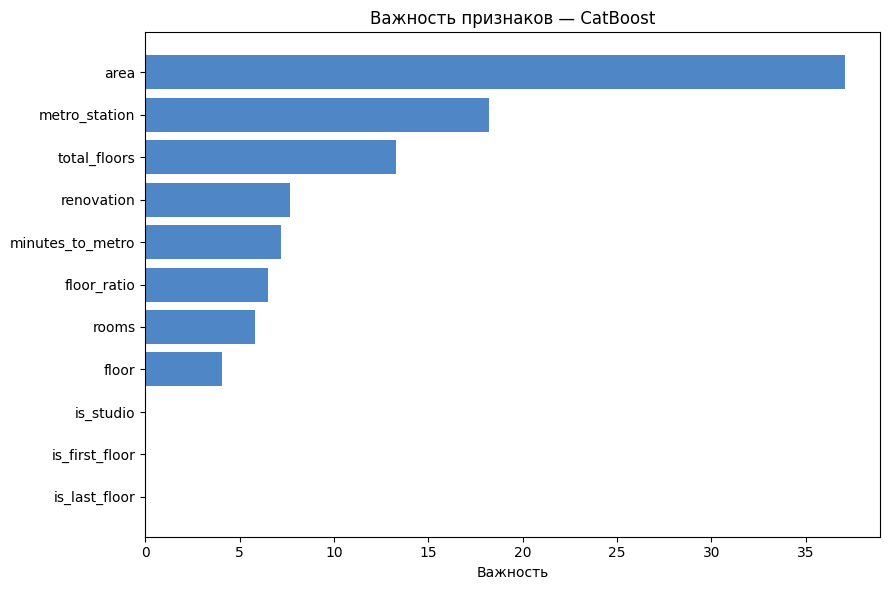

In [6]:
importance_df = plot_feature_importance(
    final_model.feature_names_,
    final_model.get_feature_importance(),
    "CatBoost",
    top_n=15,
)


Сохранение

In [7]:
# Нативное сохранение CatBoost
final_model.save_model(str(MODELS_DIR / "catboost.cbm"))

best_params_with_n = {
    **best_params,
    "iterations_after_early_stopping": int(final_model.best_iteration_),
}
save_metrics("CatBoost", metrics, best_params=best_params_with_n)
print("Модель и метрики сохранены.")


Метрики сохранены в C:\Users\roman\PycharmProjects\real_estate_ML\ml_models\metrics.json
Модель и метрики сохранены.


Сравнение всех моделей через inference

In [8]:
from inference import predict_catboost, predict_xgboost, predict_random_forest, predict_linear

example = {
    "area": 38.0, "rooms": 1.0, "floor": 5.0, "total_floors": 15,
    "minutes_to_metro": 20.0, "is_studio": 0,
    "metro_station": "Коломенская", "renovation": "Cosmetic",
}

print("=== Однушка на Коломенской ===")
print(f"  Linear:       {predict_linear(example):>15,.0f} руб.")
print(f"  RandomForest: {predict_random_forest(example):>15,.0f} руб.")
print(f"  XGBoost:      {predict_xgboost(example):>15,.0f} руб.")
print(f"  CatBoost:     {predict_catboost(example):>15,.0f} руб.")

example_center = {**example, "metro_station": "Китай-город"}
print("\n=== Та же квартира на Китай-городе ===")
print(f"  Linear:       {predict_linear(example_center):>15,.0f} руб.")
print(f"  RandomForest: {predict_random_forest(example_center):>15,.0f} руб.")
print(f"  XGBoost:      {predict_xgboost(example_center):>15,.0f} руб.")
print(f"  CatBoost:     {predict_catboost(example_center):>15,.0f} руб.")


=== Однушка на Коломенской ===
  Linear:            12,300,306 руб.
  RandomForest:      11,572,570 руб.
  XGBoost:           11,511,572 руб.
  CatBoost:          12,274,853 руб.

=== Та же квартира на Китай-городе ===
  Linear:            18,557,168 руб.
  RandomForest:      16,807,867 руб.
  XGBoost:           15,410,750 руб.
  CatBoost:          18,697,925 руб.
